## **1. Rolling Kyle's Lambda**

Starting rolling data processing...
Processing BINANCE_BTC_USDT (Loaded 21 daily files)...
Processing COINBASE_BTC_USD (Loaded 21 daily files)...
Processing COINBASE_BTC_USDT (Loaded 20 daily files)...
Processing KRAKEN_BTC_USD (Loaded 20 daily files)...
Processing KRAKEN_BTC_USDC (Loaded 21 daily files)...
Processing KRAKEN_BTC_USDT (Loaded 21 daily files)...
Processing KRAKEN_USDC_USD (Loaded 21 daily files)...
Processing KRAKEN_USDT_USD (Loaded 21 daily files)...

--- Missing Files Log ---
Missing: ORDERBOOK FIXED/2023-03-21/COINBASE_BTC_USDT_ob_2023-03-21.csv
Missing: ORDERBOOK FIXED/2023-03-21/KRAKEN_BTC_USD_ob_2023-03-21.csv


/var/folders/s8/300cjnz95yz5007dr10f40y80000gn/T/ipykernel_53822/5936075.py:177: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


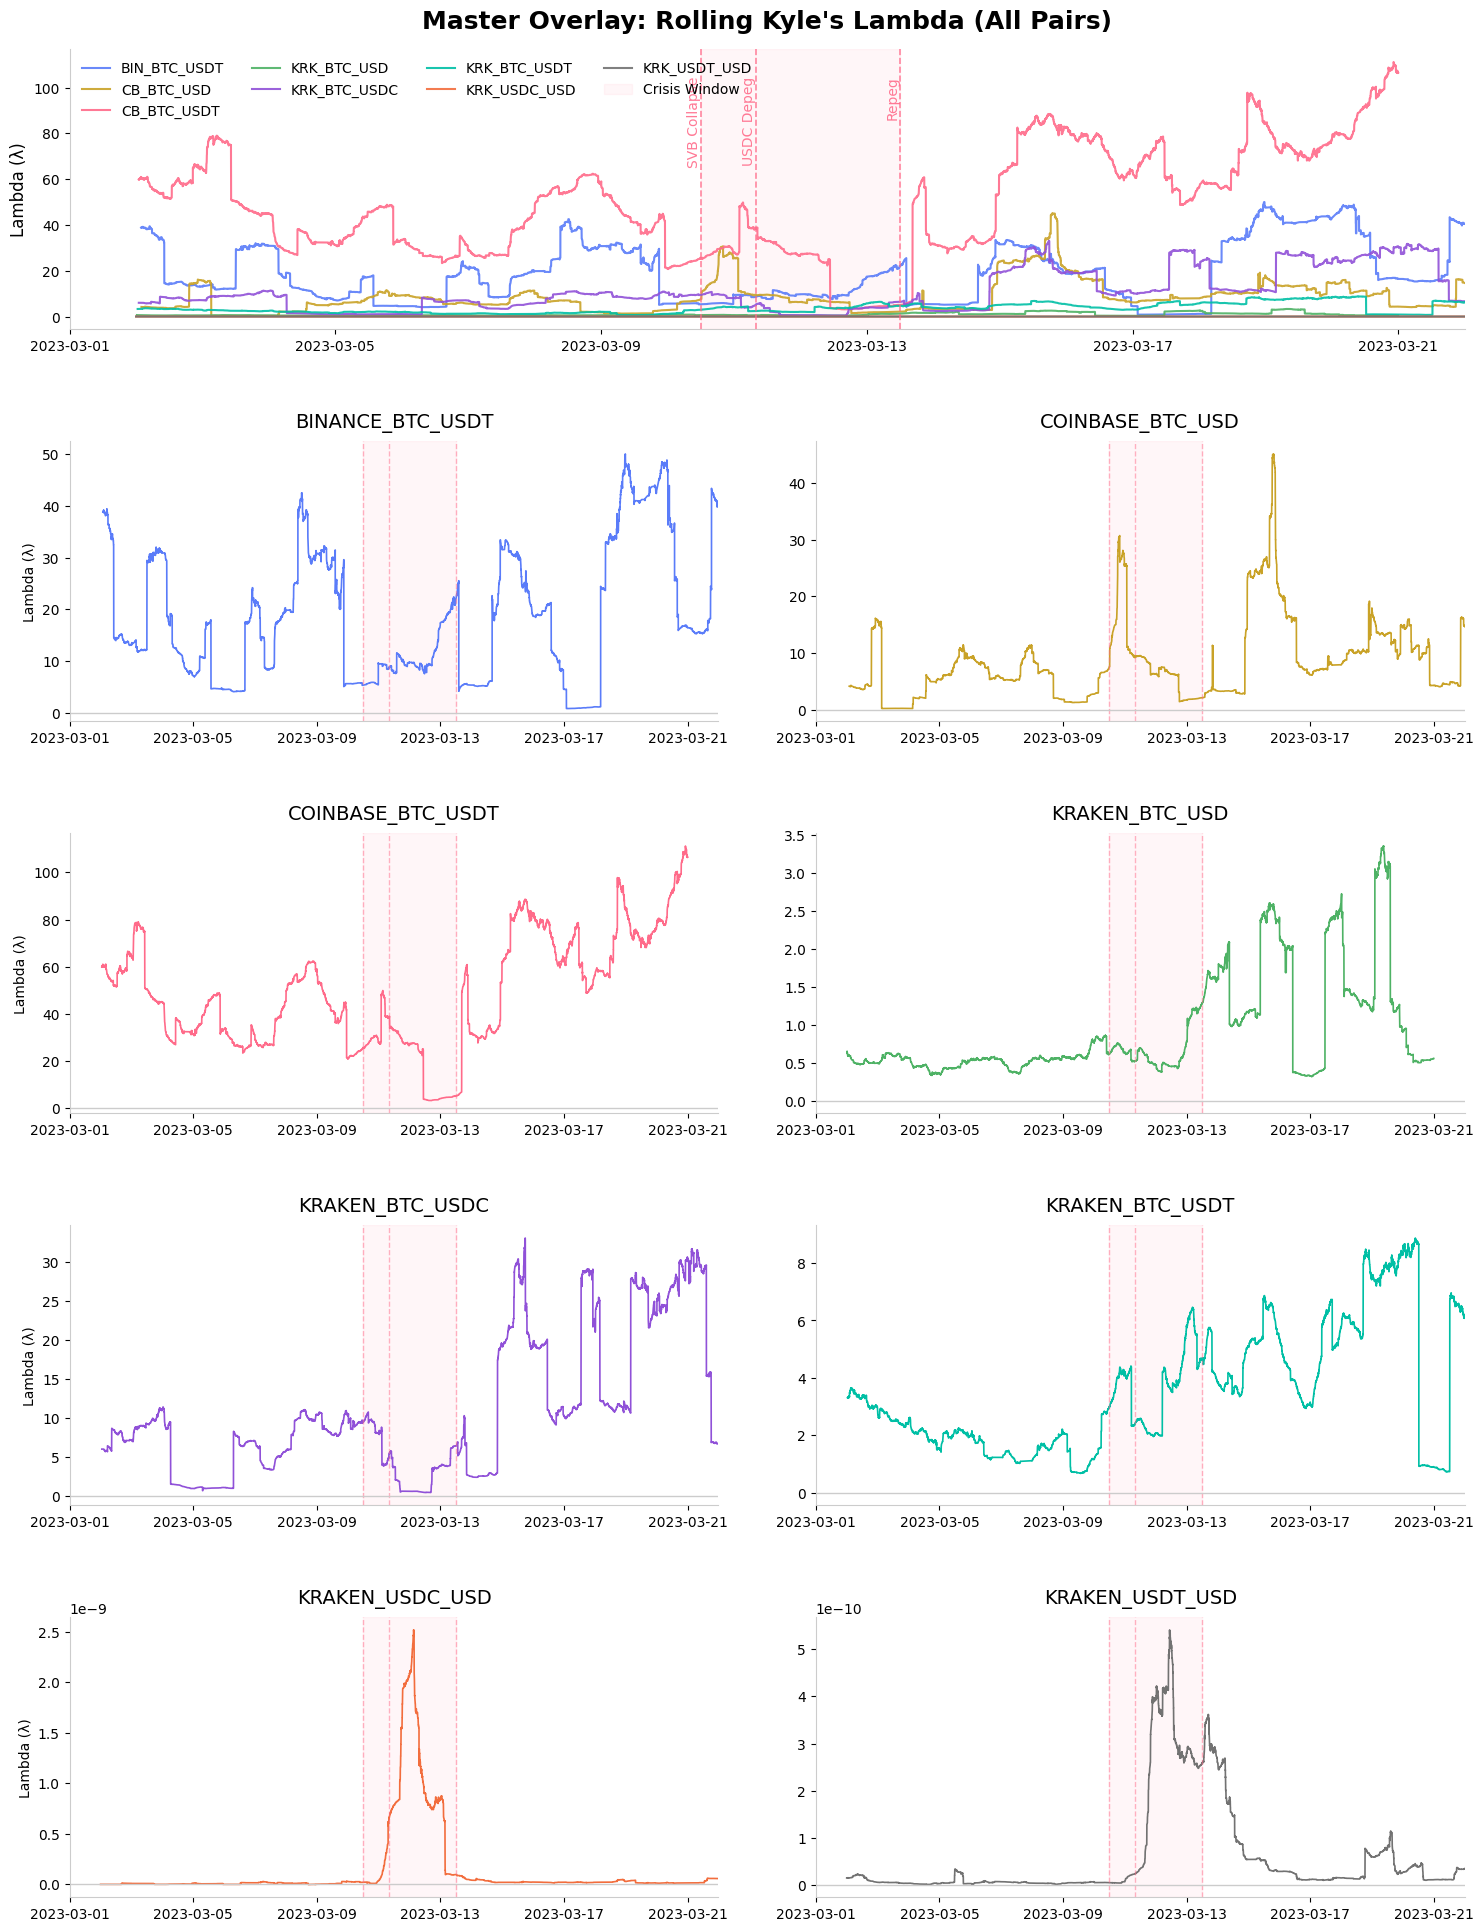


Processing complete! Formatted graph saved as 'rolling_lambda_dashboard_formatted.png'


In [ ]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# Corrected relative path based on your VS Code workspace
root_dir = Path("ORDERBOOK FIXED")

# Target Universe
pairs = [
    "BINANCE_BTC_USDT",
    "COINBASE_BTC_USD",
    "COINBASE_BTC_USDT",
    "KRAKEN_BTC_USD",
    "KRAKEN_BTC_USDC",
    "KRAKEN_BTC_USDT",
    "KRAKEN_USDC_USD",
    "KRAKEN_USDT_USD"
]

rolling_results = {}
missing_files_log = []

print("Starting rolling data processing...")

for pair in pairs:
    pair_dfs = []

    # Iterate from March 1 to March 21
    for i in range(1, 22):
        date_str = f"2023-03-{str(i).zfill(2)}"
        date_folder = root_dir / date_str
        file_name = f"{pair}_ob_{date_str}.csv"
        file_path = date_folder / file_name

        if file_path.exists():
            df = pd.read_csv(file_path)
            df.columns = df.columns.str.strip()
            df['time_exchange'] = pd.to_datetime(df['time_exchange'])
            pair_dfs.append(df)
        else:
            missing_files_log.append(str(file_path))

    if not pair_dfs:
        print(f"  [!] No data found for {pair}.")
        continue

    print(f"Processing {pair} (Loaded {len(pair_dfs)} daily files)...")

    # Concatenate and sort
    master_df = pd.concat(pair_dfs, ignore_index=True)
    master_df.sort_values(by="time_exchange", inplace=True)

    # 1. Cont et al. OFI Calculation
    master_df['delta_p'] = master_df['mid_price'].diff()

    prev_bid_p = master_df['bid_price_1'].shift(1)
    prev_bid_v = master_df['bid_size_1'].shift(1)
    prev_ask_p = master_df['ask_price_1'].shift(1)
    prev_ask_v = master_df['ask_size_1'].shift(1)

    curr_bid_p = master_df['bid_price_1']
    curr_bid_v = master_df['bid_size_1']
    curr_ask_p = master_df['ask_price_1']
    curr_ask_v = master_df['ask_size_1']

    cond_bid = [curr_bid_p > prev_bid_p, curr_bid_p == prev_bid_p, curr_bid_p < prev_bid_p]
    choice_bid = [curr_bid_v, curr_bid_v - prev_bid_v, -prev_bid_v]
    master_df['bid_imb'] = np.select(cond_bid, choice_bid, default=0)

    cond_ask = [curr_ask_p < prev_ask_p, curr_ask_p == prev_ask_p, curr_ask_p > prev_ask_p]
    choice_ask = [curr_ask_v, curr_ask_v - prev_ask_v, -prev_ask_v]
    master_df['ask_imb'] = np.select(cond_ask, choice_ask, default=0)

    master_df['OFI'] = master_df['bid_imb'] - master_df['ask_imb']
    master_df.dropna(subset=['delta_p', 'OFI'], inplace=True)

    # 2. Set index for rolling operation
    master_df.set_index('time_exchange', inplace=True)

    # 3. ROLLING OLS Regression (24-hour window = 1440 minutes)
    X = master_df['OFI']
    X = sm.add_constant(X)
    y = master_df['delta_p']

    window_size = 1440
    roll_reg = RollingOLS(endog=y, exog=X, window=window_size).fit(params_only=True)

    # Extract the rolling lambda coefficient
    rolling_results[pair] = roll_reg.params['OFI']

# Print missing files log
if missing_files_log:
    print("\n--- Missing Files Log ---")
    for missing in missing_files_log:
        print(f"Missing: {missing}")

# 4. Plotting the Multi-Graph Layout
fig = plt.figure(figsize=(18, 24), facecolor='white')
gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.4, wspace=0.15)

# Custom color map using your specified colors (#ff6b8a, #c9a227) and complementary hexes
custom_colors = ['#5a7cf9', '#c9a227', '#ff6b8a', '#4eb265', '#9051d8', '#00bfa5', '#f26d3d', '#727272']
pair_colors = dict(zip(pairs, custom_colors))

# Global X-Axis Limits to ensure all charts align perfectly
min_date = pd.to_datetime('2023-03-01').tz_localize('UTC') if master_df.index.tz is not None else pd.to_datetime('2023-03-01')
max_date = pd.to_datetime('2023-03-22').tz_localize('UTC') if master_df.index.tz is not None else pd.to_datetime('2023-03-22')

# Define Events
events = {
    'SVB Collapse': '2023-03-10 12:00:00',
    'USDC Depeg': '2023-03-11 08:00:00',
    'Repeg': '2023-03-13 12:00:00'
}
crisis_start = pd.to_datetime('2023-03-10 12:00:00')
crisis_end = pd.to_datetime('2023-03-13 12:00:00')

# Helper function to format axes cleanly
def format_axis(ax):
    ax.grid(False) # Ensure no gridlines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.set_xlim([min_date, max_date])

# --- TOP PLOT: Master Overlay ---
ax_main = fig.add_subplot(gs[0, :])
for pair in rolling_results:
    label = pair.replace("BINANCE_", "BIN_").replace("COINBASE_", "CB_").replace("KRAKEN_", "KRK_")
    ax_main.plot(rolling_results[pair].index, rolling_results[pair].values,
                 label=label, color=pair_colors[pair], linewidth=1.5, alpha=0.9)

# Crisis Shading and Event Lines
ax_main.axvspan(crisis_start, crisis_end, color='#ff6b8a', alpha=0.06, label='Crisis Window')

for event, dt_str in events.items():
    dt = pd.to_datetime(dt_str)
    ax_main.axvline(x=dt, color='#ff6b8a', linestyle='--', alpha=0.8, linewidth=1.2)
    ax_main.text(dt, ax_main.get_ylim()[1]*0.9, event, color='#ff6b8a', rotation=90,
                 verticalalignment='top', horizontalalignment='right', alpha=0.9)

format_axis(ax_main)
ax_main.set_title("Master Overlay: Rolling Kyle's Lambda (All Pairs)", fontsize=18, fontweight='bold', pad=15)
ax_main.set_ylabel("Lambda (λ)", fontsize=12)
ax_main.legend(loc='upper left', ncol=4, frameon=False)

# --- INDIVIDUAL SUBPLOTS ---
grid_locations = [(1,0), (1,1), (2,0), (2,1), (3,0), (3,1), (4,0), (4,1)]

for i, pair in enumerate(pairs):
    if pair in rolling_results:
        row, col = grid_locations[i]
        ax = fig.add_subplot(gs[row, col])

        ax.plot(rolling_results[pair].index, rolling_results[pair].values,
                color=pair_colors[pair], linewidth=1.2)

        # Crisis Shading and Event Lines for subplots
        ax.axvspan(crisis_start, crisis_end, color='#ff6b8a', alpha=0.06)
        for event, dt_str in events.items():
            dt = pd.to_datetime(dt_str)
            ax.axvline(x=dt, color='#ff6b8a', linestyle='--', alpha=0.5, linewidth=1)

        ax.axhline(0, color='#cccccc', linewidth=1, linestyle='-')
        ax.set_title(f"{pair}", fontsize=14, pad=10)
        if col == 0:
            ax.set_ylabel("Lambda (λ)", fontsize=10)

        format_axis(ax)

plt.tight_layout()
plt.savefig('rolling_lambda_dashboard_formatted.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nProcessing complete! Formatted graph saved as 'rolling_lambda_dashboard_formatted.png'")

### **Methodology: Rolling Kyle's Lambda via Cont et al. OFI**

**1. The Theoretical Framework**
Kyle's Lambda ($\lambda$) is a foundational microstructure metric used to quantify market depth and the permanent price impact of trading activity. The standard regression is modeled as:

$$\Delta P_t = \alpha + \lambda \cdot S_t + \epsilon_t$$

Where $\Delta P_t$ is the mid-price change and $S_t$ is the signed trade volume.

**2. The Order Flow Imbalance (OFI) Proxy**
Because the available dataset consists of Level 1 limit order book snapshots rather than an executed trade tape, signed trade volume cannot be directly measured. Order Flow Imbalance (OFI) serves as a robust proxy. To account for market maker algorithmic cancellations and limit order repositioning, the calculation utilizes the rigorous Cont, Kukanov, and Puhle (2014) state-conditional formula:

$$e_t = I(P^b_t \ge P^b_{t-1}) V^b_t - I(P^b_t \le P^b_{t-1}) V^b_{t-1} - I(P^a_t \le P^a_{t-1}) V^a_t + I(P^a_t \ge P^a_{t-1}) V^a_{t-1}$$

Where $P^b$ and $V^b$ represent the bid price and size, $P^a$ and $V^a$ represent the ask price and size, and $I(\cdot)$ is an indicator function.
**3. Rolling Ordinary Least Squares (OLS) Regression**
Liquidity is not stationary; it expands and contracts violently in response to macroeconomic shocks. To capture this dynamic behavior, the static OLS regression is transformed into a Rolling OLS model. By applying a 24-hour (1,440-minute) lookback window, the algorithm computes a continuous time series of $\lambda$. This prevents localized liquidity droughts from being smoothed over by monthly averages.

---

### **Results and Conclusions: The USDC Depeg Liquidity Shock**

The generated multi-plot dashboard captures the microstructure contagion caused by the Silicon Valley Bank (SVB) collapse and the subsequent USDC depeg perfectly.

**1. The Stablecoin Panic (Micro-Scale Spikes)**
* **Pairs:** `KRAKEN_USDC_USD`, `KRAKEN_USDT_USD`
* **Conclusion:** In absolute terms, the market impact for these fiat-pegged assets remains infinitesimally small (operating on a $10^{-9}$ and $10^{-10}$ scale). However, the visual structure reveals a massive relative liquidity shock exactly between the Depeg (March 11) and Repeg (March 13) events. As uncertainty peaked regarding USDC's reserves, market makers drastically widened spreads and pulled resting limit orders to avoid adverse selection, resulting in the sharp $\lambda$ peaks.

**2. The Core Liquidity Contraction**
* **Pairs:** `COINBASE_BTC_USD`, `KRAKEN_BTC_USDC`
* **Conclusion:** Both of these pairs experienced severe liquidity droughts (high $\lambda$ spikes) perfectly synchronized with the depeg. Because USDC is heavily integrated into the broader crypto ecosystem, the failure of a major quote currency's peg temporarily hollowed out the order books for primary Bitcoin pairs.

**3. The USDT "Safe Haven" Rotation**
* **Pair:** `COINBASE_BTC_USDT`
* **Conclusion:** This chart provides a fascinating counter-narrative. While most pairs saw $\lambda$ spike (indicating a liquidity drop) during the depeg, `COINBASE_BTC_USDT` saw its $\lambda$ crash toward zero precisely during the March 11–13 window. This illustrates capital rotation. As traders fled failing USDC pairs, they sought safety in USDT (Tether). This sudden influx of trading activity temporarily thickened the USDT order books, absorbing market impact.
**4. Prolonged Microstructure Friction**
* **General Observation:** Across almost all non-stablecoin pairs, the highest $\lambda$ values actually occur in the final week of March, well after the USDC repeg. This indicates that the SVB collapse triggered a prolonged period of caution among algorithmic market makers, keeping order books relatively thin as broader banking contagion fears persisted.


---
## **2. Rolling Corwin-Schultz Estimator**

Loading master_data_final_updated.csv...
Excluded: binance_btcusdc
Found 14 pairs to process.
Calculating rolling spreads...


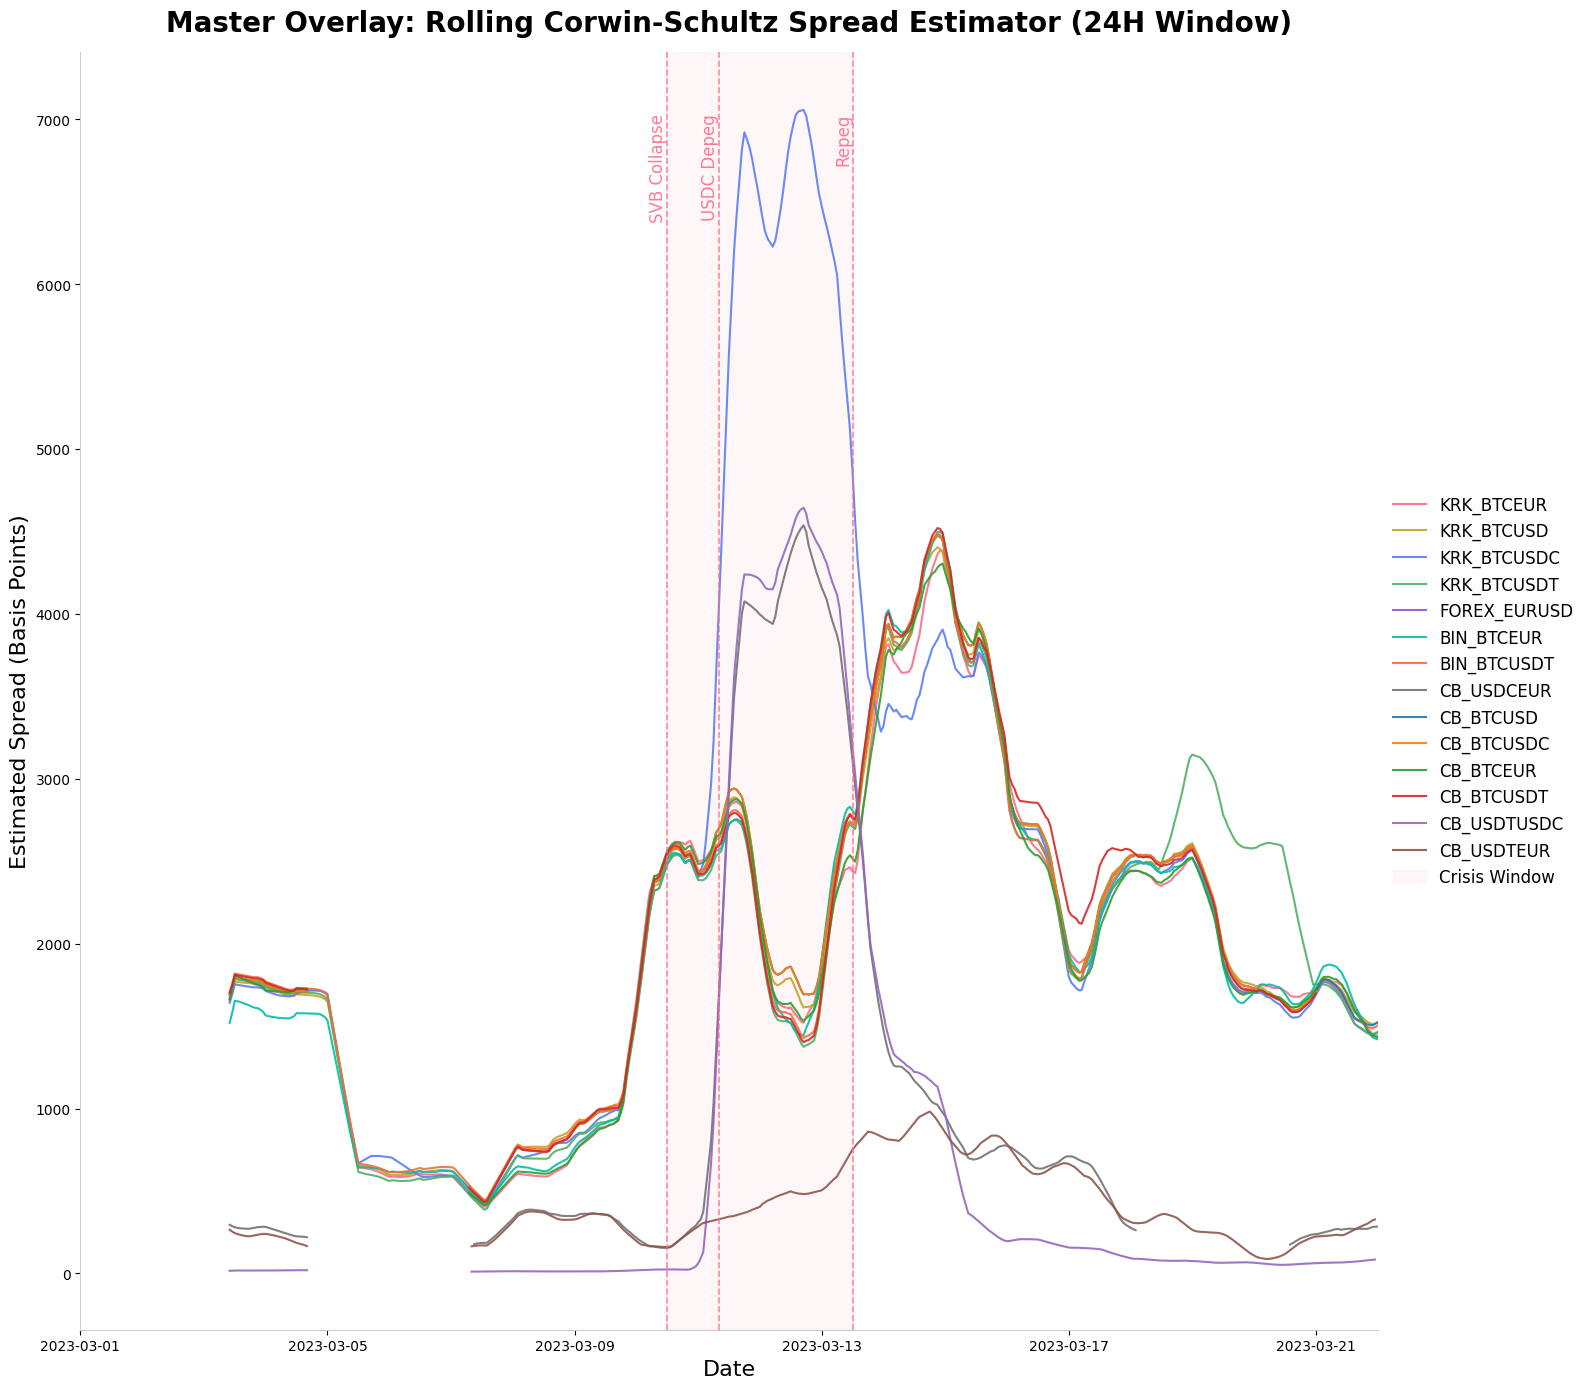


Processing complete! Formatted time-series overlay graph saved as 'rolling_corwin_schultz_overlay_formatted.png'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data and set the datetime index
file_path = 'master_data_final_updated.csv'
print(f"Loading {file_path}...")

df = pd.read_csv(file_path)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df.set_index('datetime', inplace=True)

# 2. Dynamically identify all trading pairs in the dataset
pairs = [col.replace('_high', '') for col in df.columns if col.endswith('_high')]

# Explicitly remove the binance_btcusdc outlier
if 'binance_btcusdc' in pairs:
    pairs.remove('binance_btcusdc')
    print("Excluded: binance_btcusdc")

print(f"Found {len(pairs)} pairs to process.")

# Dictionary to store the rolling spread series for each pair
rolling_results = {}

print("Calculating rolling spreads...")

# 3. Process each pair
for pair in pairs:
    high_col = f"{pair}_high"
    low_col = f"{pair}_low"

    if high_col not in df.columns or low_col not in df.columns:
        continue

    # Step A: Resample using the updated Pandas lowercase 'h' for hourly frequency
    hourly_high = df[high_col].resample('1h').max()
    hourly_low = df[low_col].resample('1h').min()

    # Step B: Calculate the Rolling 24-Hour High and Low (Period t+1)
    H_t1 = hourly_high.rolling(window=24).max()
    L_t1 = hourly_low.rolling(window=24).min()

    # Step C: Shift the series back by 24 hours to get the prior 24-hour period (Period t)
    H_t = H_t1.shift(24)
    L_t = L_t1.shift(24)

    # --- Corwin-Schultz Mathematics ---

    # Calculate Beta
    beta = (np.log(H_t / L_t))**2 + (np.log(H_t1 / L_t1))**2

    # Calculate Alpha
    alpha = (np.sqrt(2 * beta) - np.sqrt(beta)) / (3 - 2 * np.sqrt(2))

    # Calculate the CS Spread
    cs_spread = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))

    # Bound negative spreads to 0 (Standard microstructure practice)
    cs_spread = np.maximum(cs_spread, 0)

    # Step D: Apply a rolling mean to the final spread to smooth the plotted line
    smoothed_cs = cs_spread.rolling(window=12).mean()

    # Convert to Basis Points (bps) and store in the dictionary
    rolling_results[pair] = smoothed_cs * 10000

# 4. Plotting the Master Overlay Graph
plt.figure(figsize=(16, 14), facecolor='white')
ax = plt.gca()

# Custom color map using your specified colors (#ff6b8a, #c9a227) and complementary hexes
custom_colors = [
    '#ff6b8a', '#c9a227', '#5a7cf9', '#4eb265', '#9051d8',
    '#00bfa5', '#f26d3d', '#727272', '#1f77b4', '#ff7f0e',
    '#2ca02c', '#d62728', '#9467bd', '#8c564b'
]
pair_colors = dict(zip(pairs, custom_colors))

# Global X-Axis Limits to ensure all charts align perfectly
min_date = pd.to_datetime('2023-03-01').tz_localize('UTC')
max_date = pd.to_datetime('2023-03-22').tz_localize('UTC')

# Define Events and Crisis Window
events = {
    'SVB Collapse': '2023-03-10 12:00:00',
    'USDC Depeg': '2023-03-11 08:00:00',
    'Repeg': '2023-03-13 12:00:00'
}
crisis_start = pd.to_datetime('2023-03-10 12:00:00').tz_localize('UTC')
crisis_end = pd.to_datetime('2023-03-13 12:00:00').tz_localize('UTC')

# Plot each pair
for pair, series in rolling_results.items():
    # Format the labels cleanly for the legend
    label = pair.replace("binance_", "BIN_").replace("coinbase_", "CB_").replace("kraken_", "KRK_").upper()
    ax.plot(series.index, series.values, label=label, color=pair_colors.get(pair, '#000000'), linewidth=1.5, alpha=0.9)

# Crisis Shading and Event Lines
ax.axvspan(crisis_start, crisis_end, color='#ff6b8a', alpha=0.06, label='Crisis Window')

for event, dt_str in events.items():
    dt = pd.to_datetime(dt_str).tz_localize('UTC')
    ax.axvline(x=dt, color='#ff6b8a', linestyle='--', alpha=0.8, linewidth=1.2)
    ax.text(dt, ax.get_ylim()[1]*0.95, event, color='#ff6b8a', rotation=90,
            verticalalignment='top', horizontalalignment='right', alpha=0.9, fontsize=12)

# Axis Formatting (No gridlines, clean spines)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.set_xlim([min_date, max_date])

# Titles and Labels
plt.title("Master Overlay: Rolling Corwin-Schultz Spread Estimator (24H Window)", fontsize=20, fontweight='bold', pad=15)
plt.ylabel("Estimated Spread (Basis Points)", fontsize=16)
plt.xlabel("Date", fontsize=16)

# Place legend outside the plot to avoid obscuring the data lines
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12, ncol=1, frameon=False)

plt.tight_layout()
plt.savefig('rolling_corwin_schultz_overlay_formatted.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\nProcessing complete! Formatted time-series overlay graph saved as 'rolling_corwin_schultz_overlay_formatted.png'")

### **Methodology: Rolling Corwin-Schultz Spread Estimator**

**1. The Theoretical Framework**
The Corwin-Schultz (2012) High-Low Spread Estimator calculates the bid-ask spread—a proxy for market friction and transaction costs—using only observed high and low prices. The model relies on the fundamental microstructure assumption that observed high prices are almost always buyer-initiated trades executed at the ask, while low prices are seller-initiated trades executed at the bid.

By comparing the ratio of High-to-Low prices across overlapping periods, the mathematics isolate and strip away the asset's fundamental volatility, leaving behind the implied transaction costs. The calculation operates over consecutive periods ($t$ and $t+1$) in a three-step pipeline:

* **Step 1: Calculate Beta ($\beta$)**
  This isolates the squared log returns of the High-Low ranges:
  $$\beta = \left[ \ln\left(\frac{H_t}{L_t}\right) \right]^2 + \left[ \ln\left(\frac{H_{t+1}}{L_{t+1}}\right) \right]^2$$

* **Step 2: Calculate Alpha ($\alpha$)**
  This step mathematically separates the volatility component from the spread:
  $$\alpha = \frac{\sqrt{2\beta} - \sqrt{\beta}}{3 - 2\sqrt{2}}$$

* **Step 3: Calculate the CS Spread ($CS$)**
  Finally, $\alpha$ is transformed into a proportional spread estimate. Because extreme short-term volatility can occasionally force the formula to yield negative spreads, standard academic practice bounds negative estimates to 0:
  $$CS_{t,t+1} = \frac{2(e^\alpha - 1)}{1 + e^\alpha}$$

**2. Rolling Time-Series Adaptation**
To capture the dynamic expansion and contraction of liquidity during a market crisis, the static CS estimator is adapted into a continuous rolling model.
* **Data Aggregation:** The 1-minute OHLC data is resampled into 1-hour intervals to reduce high-frequency microstructure noise.
* **Rolling Window:** A 24-hour rolling window is applied. For any given hour, Period $t+1$ represents the absolute High and Low of the preceding 24 hours, and Period $t$ represents the 24 hours prior to that.
* **Smoothing:** A 12-hour moving average is applied to the final output to smooth out transient hourly spikes, revealing the true underlying liquidity trend.

---

### **Results and Conclusions**

The master overlay graph provides a stark visualization of systemic market friction before, during, and after the Silicon Valley Bank (SVB) collapse.

**1. Pre-Crisis Stratification (March 1 – March 9)**
Before the crisis window, the market operated in two distinct, stable liquidity tiers. Fiat-pegged stablecoin pairs (like `CB_USDTUSDC`) and highly liquid forex markets hovered near 0 bps, reflecting minimal transaction costs. The primary Bitcoin pairs clustered tightly between 1500 bps and 2000 bps, showcasing consistent, efficient cross-exchange arbitrage under normal conditions.

**2. The USDC Depeg Liquidity Shock (March 10 – March 13)**
As SVB collapsed and USDC lost its peg, the chart illustrates a severe, systemic breakdown in market making operations.
* **Systemic Friction:** Spreads across standard BTC pairs more than doubled, surging from the 1500 bps baseline to peak between 4000 bps and 4500 bps. Market makers drastically widened their quotes across all exchanges to protect against extreme volatility and adverse selection.
* **The USDC Epicenter:** The most extreme market failures occurred directly in USDC-denominated pairs. The `CB_USDTUSDC` pair violently broke from its 0 bps baseline to over 4500 bps. Even more severe, the `KRK_BTCUSDC` pair experienced a catastrophic liquidity drought, with its implied spread skyrocketing past 7000 bps. This indicates that trading out of USDC during the panic carried massive, punitive transaction costs.

**3. The Post-Repeg Hangover (March 14 – March 21)**
Following the official USDC repeg on March 13, spreads began to compress back toward their baselines. However, the graph reveals a distinct "liquidity hangover." Spreads remained visibly elevated (around 2500 to 3000 bps) for nearly a week after the peg was restored. This prolonged elevation suggests that market makers and algorithmic liquidity providers remained highly cautious, keeping order books thinner and transaction costs higher as broader banking contagion fears persisted in the market.